In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

all_sheets = pd.read_excel('/content/drive/MyDrive/Cadetx /ev_charging_dataset.xlsx', sheet_name=None)
sessions_df = all_sheets['sessions']

print(sessions_df['user_type'].value_counts())

user_type
public      73754
fleet       73696
delivery    73339
taxi        73235
Name: count, dtype: int64


In [3]:
user_comparison = sessions_df.groupby('user_type').agg(
    total_sessions=('session_id', 'count'),
    avg_energy_kwh=('energy_kwh', 'mean'),
    avg_session_cost=('total_cost', 'mean'),
    total_revenue=('total_cost', 'sum')
).reset_index()

print(user_comparison)

  user_type  total_sessions  avg_energy_kwh  avg_session_cost  total_revenue
0  delivery           73339       46.935722         27.761589     2036007.18
1     fleet           73696       47.040204         27.839763     2051679.16
2    public           73754       46.964837         27.803485     2050618.25
3      taxi           73235       46.917559         27.757159     2032795.53


In [10]:
import matplotlib.pyplot as plt


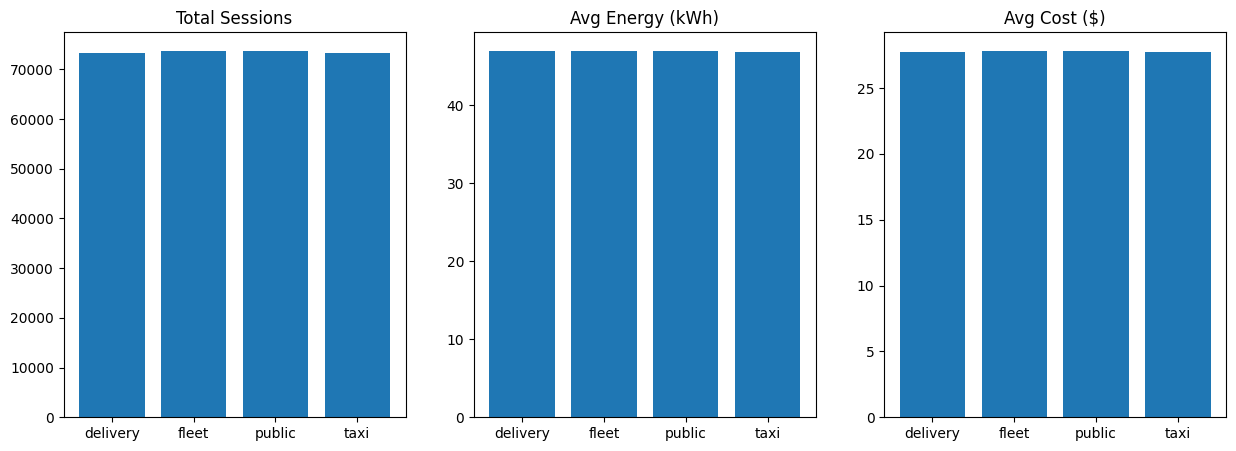

In [9]:
# Create one figure with 3 charts side by side
plt.figure(figsize=(15, 5))

# Chart 1: Total sessions
plt.subplot(1, 3, 1)
plt.bar(user_comparison['user_type'], user_comparison['total_sessions'])
plt.title('Total Sessions')

# Chart 2: Average energy
plt.subplot(1,3, 2)
plt.bar(user_comparison['user_type'], user_comparison['avg_energy_kwh'])
plt.title('Avg Energy (kWh)')

# Chart 3: Average cost
plt.subplot(1, 3, 3)
plt.bar(user_comparison['user_type'], user_comparison['avg_session_cost'])
plt.title('Avg Cost ($)')

plt.show()

In [11]:
user_comparison.to_csv('/content/drive/MyDrive/Cadetx /user_type_comparison.csv', index=False)
print("Saved!")

Saved!
